# DP Fine-Tuning of DDPM: Pretrain on ImageNet32, DP Fine-Tune on CIFAR-10

**Scientifically valid setup:**
1. **Phase 1 (public):** Pretrain a DDPM on ImageNet32 (public data, no DP needed)
2. **Phase 2 (private):** DP fine-tune on CIFAR-10 (private data) with Opacus

The privacy guarantee covers only the CIFAR-10 fine-tuning. ImageNet is treated as public.

**De et al. (2022) "Unlocking High-Accuracy DP Image Classification through Scale" techniques:**
- Augmentation multiplicity K=16: average loss over K augmentations per example before clipping (Eq. 4)
- EMA parameter averaging with warmup schedule (Sec 3.1, Appendix C.3)
- GroupNorm instead of BatchNorm (Sec 3.1) — UNet uses GroupNorm natively
- Fixed clipping norm C=1 (Appendix B.1)
- Constant learning rate, no weight decay / dropout (Sec 3.1)
- Large batch size for better DP noise averaging (Sec 3.1, Fig 2)

In [1]:
import sys, os
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
print('Repo root:', REPO_ROOT)

Repo root: <repo>


In [2]:
# ======================== CONFIG ========================

# --- Phase 1: Public pretraining on ImageNet32 ---
IMAGENET_N_SAMPLES = 50000      # how many ImageNet32 images to pretrain on
PRETRAIN_EPOCHS = 200           # 200 epochs — closer to DPDM paper's 500
PRETRAIN_BATCH_SIZE = 256
PRETRAIN_LR = 3e-4              # matches DPDM paper
PRETRAIN_SAVE_PATH = 'checkpoints/ddpm_imagenet32_small_pretrained_200ep.pt'

# --- Phase 2: DP fine-tuning on CIFAR-10 (private data) ---
# Following De et al. (2022) "Unlocking High-Accuracy DP Classification through Scale"
N_SAMPLES_PER_CLASS = 2000      # 2000 real CIFAR-10 samples per class
CLASSES = list(range(10))       # all 10 classes
EPSILONS = [1.0, 2.0, 4.0, 8.0, float('inf')]
N_GENERATE_PER_CLASS = 200

FINETUNE_EPOCHS = 100           # more iterations for DP-SGD convergence (De et al. Sec 5, Fig 6)
FINETUNE_BATCH_SIZE = 64        # smaller batch for subsampling amplification
MAX_PHYSICAL_BATCH = 4          # reduced for augmult memory: 4 * AUGMULT = 64 per fwd pass
MAX_GRAD_NORM = 1.0             # C=1 fixed (De et al. Sec 3.1, Appendix B.1)
FINETUNE_LR = 3e-4              # constant LR, no decay (De et al. Sec 3.1)
DELTA = 1e-5
UNFREEZE_FRACTION = 1.0         # fine-tune ALL params — model is small enough (1.6M)

# De et al. (2022) techniques
AUGMULT = 16                    # augmentation multiplicity K (De et al. Eq. 4, Table 2: +8% acc)
EMA_DECAY = 0.9999              # EMA decay for CIFAR (De et al. Appendix C.3: +1.3% acc)

# --- Generation / caching ---
DDPM_STEPS = 50
SEED = 42
CACHE_DIR = f'results/cifar_dpddpm_imagenet_pretrained_{PRETRAIN_EPOCHS}ep_cache'

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
from pathlib import Path
from contextlib import nullcontext
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from diffusers import UNet2DModel, DDPMScheduler
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager
from models.metrics import evaluate_fidelity_diversity
from models.train_and_generate import TensorImageDataset
from models.cifar.vae_cifar_pp import augment_batch_repeat  # De et al. augmentation multiplicity

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: mps


## Phase 1: Pretrain DDPM on ImageNet32 (Public Data, No DP)

In [4]:
# Build small UNet matching DPDM paper architecture for DP training
# DPDM uses nf=32, ch_mult=(1,2,2), attn at 16px → ~1.7M params
# Key insight: smaller models work MUCH better with DP-SGD (less noise per param)
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(32, 64, 64),       # nf=32, ch_mult=(1,2,2)
    down_block_types=(
        'DownBlock2D',
        'AttnDownBlock2D',                  # attention at 16px
        'DownBlock2D',
    ),
    up_block_types=(
        'UpBlock2D',
        'AttnUpBlock2D',
        'UpBlock2D',
    ),
    norm_num_groups=8,                      # GroupNorm with fewer groups for small channels
)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='linear')

n_params = sum(p.numel() for p in model.parameters())
print(f'UNet parameters: {n_params/1e6:.2f}M')
print(f'Architecture: nf=32, ch_mult=(1,2,2), attn@16px (DPDM-style small model)')
print(f'This is ~20x smaller than google/ddpm-cifar10-32 — much better for DP training')

UNet parameters: 1.62M
Architecture: nf=32, ch_mult=(1,2,2), attn@16px (DPDM-style small model)
This is ~20x smaller than google/ddpm-cifar10-32 — much better for DP training


In [5]:
# Load ImageNet32 for pretraining only if we do not already have the final checkpoint
from datasets import load_dataset

checkpoint_path = Path(PRETRAIN_SAVE_PATH)

if checkpoint_path.exists():
    print(f'Found pretrained checkpoint at {PRETRAIN_SAVE_PATH}; skipping ImageNet32 dataset load.')
else:
    print(f'Loading {IMAGENET_N_SAMPLES} ImageNet32 images...')
    imagenet_ds = load_dataset(
        'benjamin-paine/imagenet-1k-32x32',
        split=f'train[:{IMAGENET_N_SAMPLES}]',
    )

    # Convert to tensor
    to_tensor = transforms.ToTensor()
    imagenet_imgs = torch.stack([to_tensor(sample['image']) for sample in imagenet_ds])
    print(f'ImageNet32 tensor: {imagenet_imgs.shape}, range [{imagenet_imgs.min():.2f}, {imagenet_imgs.max():.2f}]')

    # Show some samples
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(16):
        ax = axes[i // 8, i % 8]
        ax.imshow(imagenet_imgs[i].permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.suptitle('ImageNet32 samples (public pretraining data)', fontsize=11)
    plt.tight_layout()
    plt.show()

Found pretrained checkpoint at checkpoints/ddpm_imagenet32_small_pretrained_200ep.pt; skipping ImageNet32 dataset load.


In [6]:
# Pretrain on ImageNet32 — no DP, free to train as long as we want
checkpoint_path = Path(PRETRAIN_SAVE_PATH)

if checkpoint_path.exists():
    print(f'Loading existing checkpoint from {PRETRAIN_SAVE_PATH}...')
    model.load_state_dict(torch.load(PRETRAIN_SAVE_PATH, map_location='cpu', weights_only=True))
    print('Checkpoint loaded — skipping pretraining.')
else:
    print(f'Pretraining DDPM on {IMAGENET_N_SAMPLES} ImageNet32 images for {PRETRAIN_EPOCHS} epochs...')
    print('(This will take a while on first run. Checkpoint will be saved for reuse.)')
    
    model = model.to(DEVICE)
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=PRETRAIN_LR)
    
    # Scale to [-1, 1]
    imagenet_scaled = imagenet_imgs * 2.0 - 1.0
    train_dl = DataLoader(
        TensorDataset(imagenet_scaled),
        batch_size=PRETRAIN_BATCH_SIZE,
        shuffle=True,
        drop_last=True,
    )
    
    for epoch in range(PRETRAIN_EPOCHS):
        total_loss = 0.0
        n_batches = 0
        
        for (batch,) in train_dl:
            batch = batch.to(DEVICE)
            
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (batch.shape[0],), device=DEVICE
            ).long()
            
            noise = torch.randn_like(batch)
            noisy = noise_scheduler.add_noise(batch, noise, timesteps)
            
            pred = model(noisy, timesteps).sample
            loss = F.mse_loss(pred, noise)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        print(f'  Epoch {epoch+1}/{PRETRAIN_EPOCHS} | loss={avg_loss:.4f}')
    
    # Save checkpoint
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    model_cpu = model.cpu()
    torch.save(model_cpu.state_dict(), PRETRAIN_SAVE_PATH)
    print(f'Saved pretrained model to {PRETRAIN_SAVE_PATH}')

pretrained_unet = model
print(f'\nPretrained model ready: {sum(p.numel() for p in pretrained_unet.parameters())/1e6:.1f}M params')

Loading existing checkpoint from checkpoints/ddpm_imagenet32_small_pretrained_200ep.pt...
Checkpoint loaded — skipping pretraining.

Pretrained model ready: 1.6M params


Generating samples from ImageNet32-pretrained model...


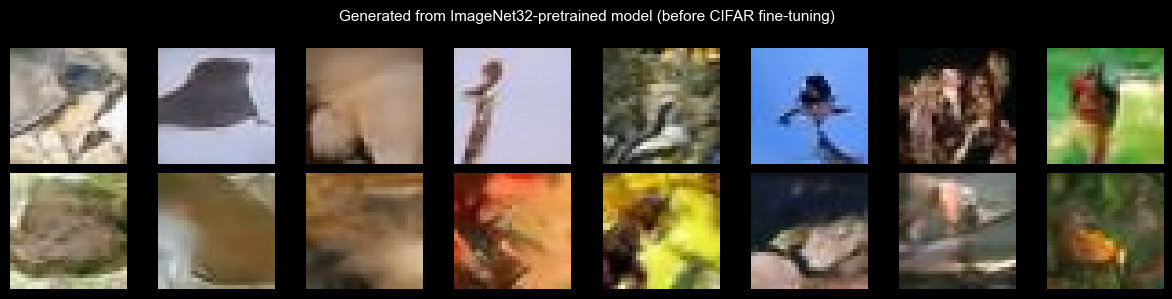

In [7]:
# Quick sanity check: generate from pretrained model (should look like blurry ImageNet)
@torch.no_grad()
def generate_ddpm(
    model: UNet2DModel,
    scheduler: DDPMScheduler,
    n_images: int,
    n_steps: int,
    device: torch.device,
    batch_size: int = 64,
) -> torch.Tensor:
    """Generate images using DDPM reverse process. Returns (N, 3, 32, 32) in [0, 1]."""
    model.eval()
    model = model.to(device)
    
    all_imgs = []
    sched = DDPMScheduler.from_config(scheduler.config)
    sched.set_timesteps(n_steps)
    
    for start in range(0, n_images, batch_size):
        bs = min(batch_size, n_images - start)
        sample = torch.randn(bs, 3, 32, 32, device=device)
        
        for t in sched.timesteps:
            t_batch = t.expand(bs).to(device)
            pred = model(sample, t_batch).sample
            sample = sched.step(pred, t, sample).prev_sample
        
        imgs = ((sample + 1.0) / 2.0).clamp(0.0, 1.0).cpu()
        all_imgs.append(imgs)
    
    return torch.cat(all_imgs, dim=0)


print('Generating samples from ImageNet32-pretrained model...')
pretrain_samples = generate_ddpm(pretrained_unet, noise_scheduler, 16, DDPM_STEPS, DEVICE)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(pretrain_samples[i].permute(1, 2, 0).numpy())
    ax.axis('off')
plt.suptitle('Generated from ImageNet32-pretrained model (before CIFAR fine-tuning)', fontsize=11)
plt.tight_layout()
plt.show()

## Phase 2: DP Fine-Tune on CIFAR-10 (Private Data)

In [8]:
# Load CIFAR-10 (this is the "private" data)
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
full_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

all_imgs = torch.stack([full_train[i][0] for i in range(len(full_train))])
all_labels = torch.tensor([full_train[i][1] for i in range(len(full_train))])

class_data = {}
for cls in CLASSES:
    mask = all_labels == cls
    cls_imgs = all_imgs[mask][:N_SAMPLES_PER_CLASS]
    class_data[cls] = cls_imgs
    print(f'Class {cls} ({CIFAR10_CLASSES[cls]}): {cls_imgs.shape[0]} samples')

real_all = torch.cat([class_data[c] for c in CLASSES])
real_labels = torch.cat([torch.full((class_data[c].shape[0],), c) for c in CLASSES])
print(f'\nTotal private CIFAR-10 samples: {real_all.shape[0]}')

Class 0 (airplane): 2000 samples
Class 1 (automobile): 2000 samples
Class 2 (bird): 2000 samples
Class 3 (cat): 2000 samples
Class 4 (deer): 2000 samples
Class 5 (dog): 2000 samples
Class 6 (frog): 2000 samples
Class 7 (horse): 2000 samples
Class 8 (ship): 2000 samples
Class 9 (truck): 2000 samples

Total private CIFAR-10 samples: 20000


In [9]:
def dp_finetune_ddpm(
    images: torch.Tensor,
    base_model: UNet2DModel,
    scheduler: DDPMScheduler,
    epsilon: float,
    epochs: int,
    batch_size: int,
    lr: float,
    max_grad_norm: float,
    delta: float,
    device: torch.device,
    augmult: int = 1,
    ema_decay: float = 0.9999,
) -> UNet2DModel:
    """DP fine-tune a pretrained DDPM on private CIFAR-10 data.
    
    Follows De et al. (2022) "Unlocking High-Accuracy DP Classification through Scale":
    - Augmentation multiplicity (Eq. 4): average denoising loss over K augmented
      views of each image before per-example gradient clipping.
    - EMA with warmup (Sec 3.1, Appendix C.3): decay_t = min(ema_decay, (1+t)/(10+t)).
    - No explicit regularization: weight_decay=0, no dropout (Sec 3.1).
    - Constant learning rate, fixed clipping norm C=1.
    """
    
    model = copy.deepcopy(base_model)
    
    if UNFREEZE_FRACTION < 1.0:
        all_params = list(model.named_parameters())
        n_unfreeze = max(1, int(len(all_params) * UNFREEZE_FRACTION))
        for p in model.parameters():
            p.requires_grad = False
        for name, p in all_params[-n_unfreeze:]:
            p.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'  Trainable: {trainable/1e6:.2f}M / {total/1e6:.2f}M ({100*trainable/total:.0f}%)')
    
    model = model.to(device)
    model.train()
    
    # No weight decay (De et al. Sec 3.1: "we do not use weight decay or dropout")
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=0.0,
    )
    
    images_scaled = images * 2.0 - 1.0
    dl = DataLoader(
        TensorDataset(images_scaled),
        batch_size=batch_size,
        shuffle=True,
        drop_last=len(images_scaled) > batch_size,
    )
    
    is_dp = epsilon < float('inf')
    
    if is_dp:
        privacy_engine = PrivacyEngine()
        model, optimizer, dl = privacy_engine.make_private_with_epsilon(
            module=model,
            optimizer=optimizer,
            data_loader=dl,
            target_epsilon=epsilon,
            target_delta=delta,
            epochs=epochs,
            max_grad_norm=max_grad_norm,
        )
        print(f'  Opacus noise_multiplier: {optimizer.noise_multiplier:.4f}')
    
    # --- EMA setup (De et al. Sec 3.1, Appendix C.3) ---
    base_ref = model._module if is_dp else model
    ema_state = {n: p.data.clone() for n, p in base_ref.named_parameters() if p.requires_grad}
    step_count = 0
    
    for epoch in range(epochs):
        total_loss = 0.0
        n_batches = 0
        
        if is_dp:
            ctx = BatchMemoryManager(
                data_loader=dl,
                max_physical_batch_size=MAX_PHYSICAL_BATCH,
                optimizer=optimizer,
            )
        else:
            ctx = nullcontext(dl)
        
        with ctx as active_dl:
            for (batch,) in active_dl:
                batch = batch.to(device)  # (b, 3, 32, 32) in [-1, 1]
                b = batch.shape[0]
                
                # --- Augmentation Multiplicity (De et al. Eq. 4) ---
                # Average denoising loss over K augmented views per image.
                # Each view gets its own random timestep and noise for
                # additional variance reduction.
                if augmult > 1:
                    batch_01 = (batch + 1.0) / 2.0
                    batch_aug = augment_batch_repeat(batch_01, augmult=augmult, pad=4)
                    batch_aug = batch_aug * 2.0 - 1.0
                else:
                    batch_aug = batch
                
                ba = batch_aug.shape[0]  # b * augmult
                
                timesteps = torch.randint(
                    0, scheduler.config.num_train_timesteps,
                    (ba,), device=device
                ).long()
                noise = torch.randn_like(batch_aug)
                noisy = scheduler.add_noise(batch_aug, noise, timesteps)
                
                pred = model(noisy, timesteps).sample
                
                # Per-sample MSE
                loss_per = F.mse_loss(pred, noise, reduction='none').view(ba, -1).mean(dim=1)
                
                # Average over augmentation multiplicity (De et al. Eq. 4)
                if augmult > 1:
                    loss_per = loss_per.view(b, augmult).mean(dim=1)
                
                loss = loss_per.mean()
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                # --- EMA update with warmup (De et al. Appendix C.3) ---
                step_count += 1
                decay_t = min(ema_decay, (1 + step_count) / (10 + step_count))
                for n, p in base_ref.named_parameters():
                    if p.requires_grad and n in ema_state:
                        ema_state[n].mul_(decay_t).add_(p.data, alpha=1.0 - decay_t)
                
                total_loss += loss.item()
                n_batches += 1
        
        avg_loss = total_loss / max(n_batches, 1)
        if epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1:
            if is_dp:
                eps_so_far = privacy_engine.get_epsilon(delta)
                print(f'  Epoch {epoch+1}/{epochs} | loss={avg_loss:.4f} | ε={eps_so_far:.2f}')
            else:
                print(f'  Epoch {epoch+1}/{epochs} | loss={avg_loss:.4f} | no DP')
    
    # --- Copy EMA weights (De et al. Sec 3.1) ---
    # "parameter averaging techniques do not incur any additional privacy cost"
    for n, p in base_ref.named_parameters():
        if p.requires_grad and n in ema_state:
            p.data.copy_(ema_state[n])
    
    if is_dp:
        final_eps = privacy_engine.get_epsilon(delta)
        print(f'  Final ε = {final_eps:.2f}')
        return model._module
    return model

In [ ]:
# Run the DP fine-tuning sweep with resume support
cache_root = Path(CACHE_DIR)
cache_root.mkdir(parents=True, exist_ok=True)


def epsilon_cache_tag(epsilon: float) -> str:
    if epsilon == float('inf'):
        return 'inf'
    return f'{epsilon:.1f}'.replace('.', 'p')


results = {}

for eps in EPSILONS:
    eps_str = f'{eps:.1f}' if eps < float('inf') else '∞'
    eps_tag = epsilon_cache_tag(eps)
    eps_cache_path = cache_root / f'epsilon_{eps_tag}.pt'

    print(f'\n{"="*60}')
    print(f'Epsilon = {eps_str}')
    print(f'{"="*60}')

    if eps_cache_path.exists():
        cached_eps = torch.load(eps_cache_path, map_location='cpu', weights_only=False)
        results[eps] = {
            'images': cached_eps['images'],
            'labels': cached_eps['labels'],
        }
        print(f'Loaded cached epsilon result from {eps_cache_path}')
        print(f'Total synthetic for ε={eps_str}: {results[eps]["images"].shape[0]}')
        continue

    syn_images_list = []
    syn_labels_list = []

    for cls in CLASSES:
        cls_name = CIFAR10_CLASSES[cls]
        cls_cache_path = cache_root / f'epsilon_{eps_tag}_class_{cls}.pt'
        print(f'\n--- Class {cls} ({cls_name}) ---')

        if cls_cache_path.exists():
            cached_cls = torch.load(cls_cache_path, map_location='cpu', weights_only=False)
            syn_imgs = cached_cls['images']
            syn_lbls = cached_cls['labels']
            print(f'  Loaded cached class result from {cls_cache_path}')
        else:
            finetuned = dp_finetune_ddpm(
                images=class_data[cls],
                base_model=pretrained_unet,
                scheduler=noise_scheduler,
                epsilon=eps,
                epochs=FINETUNE_EPOCHS,
                batch_size=FINETUNE_BATCH_SIZE,
                lr=FINETUNE_LR,
                max_grad_norm=MAX_GRAD_NORM,
                delta=DELTA,
                device=DEVICE,
                augmult=AUGMULT,           # De et al. Eq. 4
                ema_decay=EMA_DECAY,       # De et al. Sec 3.1
            )

            print(f'  Generating {N_GENERATE_PER_CLASS} images...')
            syn_imgs = generate_ddpm(
                model=finetuned,
                scheduler=noise_scheduler,
                n_images=N_GENERATE_PER_CLASS,
                n_steps=DDPM_STEPS,
                device=DEVICE,
            ).cpu()
            syn_lbls = torch.full((syn_imgs.shape[0],), cls, dtype=torch.long)

            torch.save(
                {
                    'epsilon': eps,
                    'class_idx': cls,
                    'class_name': cls_name,
                    'images': syn_imgs,
                    'labels': syn_lbls,
                },
                cls_cache_path,
            )
            print(f'  Saved class cache to {cls_cache_path}')

        syn_images_list.append(syn_imgs)
        syn_labels_list.append(syn_lbls)
        print(f'  Generated: {syn_imgs.shape}')

    results[eps] = {
        'images': torch.cat(syn_images_list),
        'labels': torch.cat(syn_labels_list),
    }
    torch.save(results[eps], eps_cache_path)
    print(f'Saved epsilon cache to {eps_cache_path}')
    print(f'\nTotal synthetic for ε={eps_str}: {results[eps]["images"].shape[0]}')


Epsilon = 1.0

--- Class 0 (airplane) ---
  Trainable: 1.62M / 1.62M (100%)


<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
03/20/2026 17:01:11:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


  Opacus noise_multiplier: 6.8750


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


  Epoch 1/100 | loss=0.0315 | ε=0.09
  Epoch 11/100 | loss=0.0295 | ε=0.31
  Epoch 21/100 | loss=0.0300 | ε=0.43
  Epoch 31/100 | loss=0.0299 | ε=0.53
  Epoch 41/100 | loss=0.0300 | ε=0.61


## Visualize Results

In [ ]:
# Show generated images: one row per epsilon, 8 random samples
n_show = 8
n_eps = len(EPSILONS)
n_cls = len(CLASSES)

# Compact view: one row per epsilon with mixed classes
fig, axes = plt.subplots(n_eps, n_show, figsize=(n_show * 1.5, n_eps * 1.5))

for i, eps in enumerate(EPSILONS):
    eps_str = f'ε={eps:.0f}' if eps < float('inf') else 'No DP'
    syn_imgs = results[eps]['images']
    
    # Random sample
    idx = torch.randperm(syn_imgs.shape[0])[:n_show]
    for j in range(n_show):
        ax = axes[i, j] if n_eps > 1 else axes[j]
        ax.imshow(syn_imgs[idx[j]].permute(1, 2, 0).numpy())
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(eps_str, fontsize=9, rotation=0, labelpad=40)

plt.suptitle(f'DP-DDPM: ImageNet32 pretrained ({PRETRAIN_EPOCHS}ep) → CIFAR-10 DP fine-tuned', fontsize=12)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig(f'results/cifar_dp_ddpm_imagenet_pretrained_{PRETRAIN_EPOCHS}ep_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Per-class view for no-DP to see class specialization
fig, axes = plt.subplots(n_cls, n_show, figsize=(n_show * 1.5, n_cls * 1.5))

best_eps = float('inf')  # show no-DP for best-case class specialization
syn_imgs = results[best_eps]['images']
syn_lbls = results[best_eps]['labels']

for i, cls in enumerate(CLASSES):
    mask = syn_lbls == cls
    cls_imgs = syn_imgs[mask][:n_show]
    for j in range(n_show):
        ax = axes[i, j] if n_cls > 1 else axes[j]
        if j < cls_imgs.shape[0]:
            ax.imshow(cls_imgs[j].permute(1, 2, 0).numpy())
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CIFAR10_CLASSES[cls], fontsize=8, rotation=0, labelpad=45)

plt.suptitle('Generated per class (No DP, best case)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Real CIFAR-10 samples for comparison
fig, axes = plt.subplots(n_cls, n_show, figsize=(n_show * 1.5, n_cls * 1.5))

for i, cls in enumerate(CLASSES):
    for j in range(n_show):
        ax = axes[i, j] if n_cls > 1 else axes[j]
        ax.imshow(class_data[cls][j].permute(1, 2, 0).numpy())
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CIFAR10_CLASSES[cls], fontsize=8, rotation=0, labelpad=45)

plt.suptitle('Real CIFAR-10 samples (for comparison)', fontsize=12)
plt.tight_layout()
plt.show()

## Quality Metrics & Utility

In [ ]:
import pandas as pd

metrics_rows = []

for eps in EPSILONS:
    eps_str = f'{eps:.1f}' if eps < float('inf') else 'inf'
    syn_imgs = results[eps]['images']
    
    print(f'\nEvaluating ε={eps_str}...')
    
    real_ds = TensorImageDataset(real_all, target_size=None)
    fake_ds = TensorImageDataset(syn_imgs, target_size=None)
    
    m = evaluate_fidelity_diversity(
        real_ds, fake_ds,
        alpha=0.90, beta=0.90,
        batch_size=256,
        backbone='resnet18',
        input_size=32,
        device='cpu',
    )
    
    row = {'epsilon': eps_str, **m}
    metrics_rows.append(row)
    print(f'  α-precision: {m["alpha_precision"]:.3f}')
    print(f'  β-recall:    {m["beta_recall"]:.3f}')
    print(f'  authenticity: {m["authenticity"]:.3f}')

df = pd.DataFrame(metrics_rows)
print('\n' + '='*50)
print(df.to_string(index=False))
df.to_csv(f'results/cifar_dp_ddpm_imagenet_pretrained_{PRETRAIN_EPOCHS}ep_metrics.csv', index=False)

In [ ]:
# Downstream utility: train classifier on synthetic, test on real
from models.cifar.cifar_cnn import CIFAR_CNN
from sklearn.metrics import accuracy_score, f1_score
import torch.nn as nn

test_imgs = torch.stack([full_test[i][0] for i in range(len(full_test))])
test_labels = torch.tensor([full_test[i][1] for i in range(len(full_test))])
test_mask = torch.zeros(len(test_labels), dtype=torch.bool)
for c in CLASSES:
    test_mask |= (test_labels == c)
test_imgs = test_imgs[test_mask]
test_labels = test_labels[test_mask]

label_map = {c: i for i, c in enumerate(CLASSES)}
test_labels_mapped = torch.tensor([label_map[l.item()] for l in test_labels])

print(f'Test set: {test_imgs.shape[0]} images, {len(CLASSES)} classes')

utility_rows = []

for eps in EPSILONS:
    eps_str = f'{eps:.1f}' if eps < float('inf') else 'inf'
    syn_imgs = results[eps]['images']
    syn_lbls = results[eps]['labels']
    syn_lbls_mapped = torch.tensor([label_map[l.item()] for l in syn_lbls])
    
    clf = CIFAR_CNN()
    clf.classifier[-1] = nn.Linear(512, len(CLASSES))
    clf = clf.to(DEVICE)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    
    train_dl = DataLoader(
        TensorDataset(syn_imgs, syn_lbls_mapped),
        batch_size=64, shuffle=True,
    )
    
    clf.train()
    for epoch in range(20):
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = F.cross_entropy(clf(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
    
    clf.eval()
    all_preds = []
    with torch.no_grad():
        for start in range(0, len(test_imgs), 256):
            xb = test_imgs[start:start+256].to(DEVICE)
            preds = clf(xb).argmax(dim=1).cpu()
            all_preds.append(preds)
    all_preds = torch.cat(all_preds)
    
    acc = accuracy_score(test_labels_mapped, all_preds)
    f1 = f1_score(test_labels_mapped, all_preds, average='macro')
    
    utility_rows.append({'epsilon': eps_str, 'accuracy': acc, 'f1_macro': f1})
    print(f'ε={eps_str:>5s} | Acc={acc:.3f} | F1={f1:.3f}')

df_util = pd.DataFrame(utility_rows)
print('\n' + df_util.to_string(index=False))
df_util.to_csv(f'results/cifar_dp_ddpm_imagenet_pretrained_{PRETRAIN_EPOCHS}ep_utility.csv', index=False)

In [ ]:
# Combined plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

eps_labels = [f'ε={e:.0f}' if e < float('inf') else 'No DP' for e in EPSILONS]
x = range(len(EPSILONS))

# Quality
ax1.plot(x, [r['alpha_precision'] for r in metrics_rows], 'o-', label='α-Precision', linewidth=2)
ax1.plot(x, [r['beta_recall'] for r in metrics_rows], 's-', label='β-Recall', linewidth=2)
ax1.plot(x, [r['authenticity'] for r in metrics_rows], '^-', label='Authenticity', linewidth=2)
ax1.set_xticks(x)
ax1.set_xticklabels(eps_labels)
ax1.set_ylabel('Score')
ax1.set_title('Image Quality')
ax1.legend()
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Utility
ax2.plot(x, [r['accuracy'] for r in utility_rows], 'o-', label='Accuracy', linewidth=2, color='tab:red')
ax2.plot(x, [r['f1_macro'] for r in utility_rows], 's-', label='F1 Macro', linewidth=2, color='tab:orange')
ax2.axhline(y=1.0/len(CLASSES), color='gray', linestyle='--', alpha=0.5, label=f'Random ({1.0/len(CLASSES):.0%})')
ax2.set_xticks(x)
ax2.set_xticklabels(eps_labels)
ax2.set_ylabel('Score')
ax2.set_title('Downstream Utility')
ax2.legend()
ax2.set_ylim(0, 1.0)
ax2.grid(True, alpha=0.3)

fig.suptitle(f'DP-DDPM (ImageNet32 pretrained {PRETRAIN_EPOCHS}ep → CIFAR-10 DP fine-tune)\n'
             f'{N_SAMPLES_PER_CLASS} samples/class, {len(CLASSES)} classes, {FINETUNE_EPOCHS} ft epochs',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'results/cifar_dp_ddpm_imagenet_pretrained_{PRETRAIN_EPOCHS}ep_combined.png', dpi=150)
plt.show()